# AI in Fluids - Week 3 Lab 2
## From a mini DSMC cavity to an optional validation-quality molecular cavity

This notebook continues the **same lid-driven cavity story** used in Week 1. Week 1 solved a continuum cavity and validated it against Ghia. Here, representative particles move, reflect from walls, collide stochastically inside cells, and are averaged to create noisy macroscopic fields.

### Two-part scope

**Part I - required, CPU:** the dimensionless mini DSMC-style model in Sections 0-10. It is deliberately small enough to run during the lab and is used to learn movement-collision splitting, diffuse walls, stochastic elastic collisions, sampling, noise, and ML-ready metadata.

**Part II - optional bonus, GPU:** the Mohammadzadeh-type argon cavity in Section 11. This extension uses the supplied CuPy VHS-NTC solver, includes a long run that may take roughly **one to two hours** depending on the GPU, and asks for a limited grid/PPC independence check plus validation at \(Kn=0.05\).

### Hardware rule

- Run the **required mini cavity on a CPU**.
- Run the **optional production cavity on an NVIDIA GPU** using CuPy.
- A CPU-only/login-node production run is not accepted for the optional extension. The solver's `--debug-cpu` mode is only for tiny development tests, not scientific results.

### Submission reminder

The submission structure does **not** change. Submit only:

1. the completed Lab 1 notebook,
2. this completed Lab 2 notebook, and
3. one Week-3 PDF report containing all final written answers and any optional-extension results.

Do not upload extra folders as separate required deliverables; keep optional plots, tables, and validation output visible in this notebook and summarized in the same PDF report.


## 0. Article-aligned solver validation comes first

<!-- MIE690A article-aligned validation v3 -->

This is a validation of **our executed HS--NTC DSMC solver**, not a pasted literature panel. The target is the hard-sphere argon cavity reported by Mohammadzadeh *et al.* at $Re=1.5$, $Kn=0.1$, and $Ma=0.09$. The observable is $p/p_0$ along A(bottom-left)--B(top-left)--C(top-right)--D(bottom-right)--A.

The black markers below were extracted from the vector paths of the published figure. The blue curve is our retained $60^2$, 50-particles-per-cell run with 6000 field samples. The ochre curve and band are the mean and run-to-run $\pm1\sigma$ spread of three independent $40^2$ runs. The second panel reports pointwise discrepancies so that visually overlapping curves are not mistaken for identical results.


In [1]:
from pathlib import Path
import sys

def locate_course_root(start=Path.cwd()):
    for origin in (Path(start).resolve(), Path.cwd().resolve()):
        for candidate in (origin, *origin.parents):
            if (candidate / "common" / "article_validation.py").exists():
                return candidate
    raise FileNotFoundError(
        "Run this notebook inside the complete MIE690A release; common/article_validation.py is required."
    )

COURSE_ROOT = locate_course_root()
sys.path.insert(0, str(COURSE_ROOT / "common"))
from article_validation import (
    build_dsmc_wall_pressure_validation,
    build_ghia_velocity_validation,
    build_pressure_validation,
)
print("Course root:", COURSE_ROOT)


Course root: /workspace/scratch/b22ffb32910d/course_release_v3/MIE690A_AI_in_Fluid_Mechanics


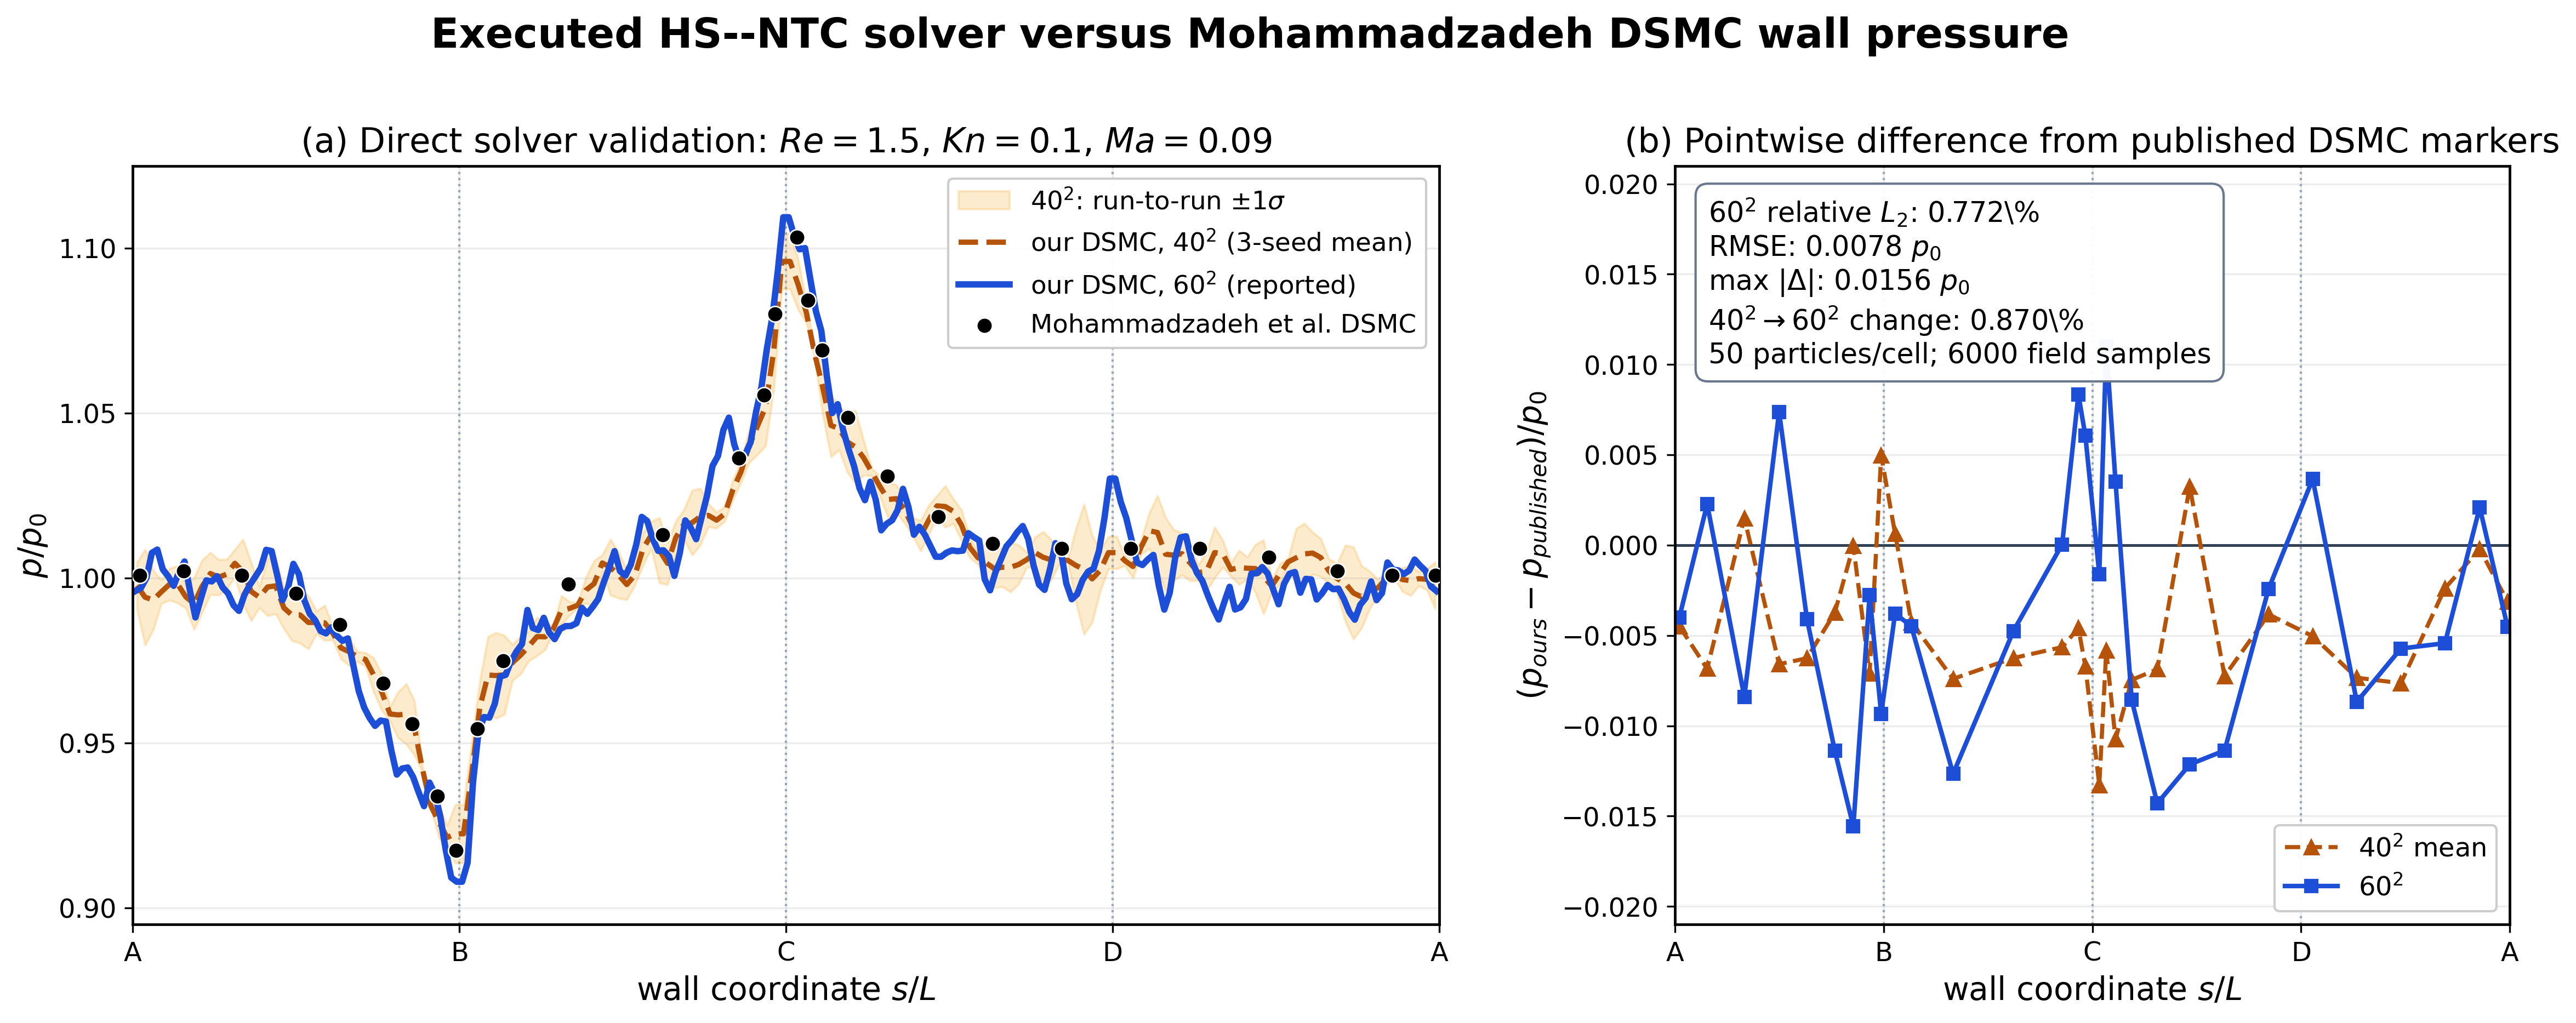

relative_l2,rmse_over_p0,max_abs_over_p0,grid_change_40_to_60,fine_run,coarse_runs
0.007723,0.007801,0.015575,0.008696,ref_n60_seed07,"[ref_n40_seed07, ref_n40_seed19, ref_n40_seed31]"


Paper-ready file: /workspace/scratch/b22ffb32910d/course_release_v3/MIE690A_AI_in_Fluid_Mechanics/results/article_figures/fig10a_mohammadzadeh_validation.pdf


In [2]:
from IPython.display import Image, display
import pandas as pd

dsmc_validation = build_dsmc_wall_pressure_validation(COURSE_ROOT)
display(Image(filename=str(dsmc_validation["figure"]["png"]), width=1150))
display(pd.DataFrame([dsmc_validation["metrics"]]))
print("Paper-ready file:", dsmc_validation["figure"]["pdf"])


In [3]:
# Optional full recomputation with the same solver kernel and declared budgets.
# The retained outputs above are genuine completed runs. Turn this on only when you
# want to regenerate all four realizations (CPU time depends strongly on hardware).
RUN_FULL_DSMC_VALIDATION = False

if RUN_FULL_DSMC_VALIDATION:
    import subprocess
    runner = COURSE_ROOT / "notebooks" / "week03" / "run_wall_pressure_case.py"
    output = COURSE_ROOT / "results" / "dsmc_validation" / "runs"
    specifications = [
        (40, 7, 12000, 4000, 0.05, "ref_n40_seed07"),
        (40, 19, 12000, 4000, 0.05, "ref_n40_seed19"),
        (40, 31, 12000, 4000, 0.05, "ref_n40_seed31"),
        (60, 7, 18000, 6000, 0.04, "ref_n60_seed07"),
    ]
    for grid, seed, steps, sample_start, dt_factor, case_name in specifications:
        command = [
            sys.executable, str(runner), "--grid", str(grid), "--ppc", "50",
            "--steps", str(steps), "--sample-start", str(sample_start),
            "--sample-stride", "2", "--dt-factor", str(dt_factor),
            "--seed", str(seed), "--output-dir", str(output), "--case-name", case_name,
        ]
        print("$", " ".join(command))
        subprocess.run(command, cwd=runner.parent, check=True)
    dsmc_validation = build_dsmc_wall_pressure_validation(COURSE_ROOT)
    display(Image(filename=str(dsmc_validation["figure"]["png"]), width=1150))
else:
    print("Using four retained completed runs; set the switch to rerun the production validation.")


Using four retained completed runs; set the switch to rerun the production validation.


## 0. Imports

In [ ]:
from dataclasses import dataclass, asdict
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

np.set_printoptions(precision=5, suppress=True)

## 1. DSMC-style flowchart

In [ ]:
labels = [
    "Initialize\nparticles",
    "Move",
    "Apply wall\nreflection",
    "Index into\ncells",
    "Select and\ncollide pairs",
    "Sample and\naverage fields",
]

fig, ax = plt.subplots(figsize=(12, 2.5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 2.5)
ax.axis("off")
for i, label in enumerate(labels):
    x = 0.15 + 1.95*i
    box = FancyBboxPatch((x, 0.75), 1.65, 0.95, boxstyle="round,pad=0.04",
                         linewidth=1.5, edgecolor="0.15", facecolor="0.92")
    ax.add_patch(box)
    ax.text(x+0.825, 1.225, label, ha="center", va="center", fontsize=10, weight="bold")
    if i < len(labels)-1:
        ax.add_patch(FancyArrowPatch((x+1.65, 1.225), (x+1.92, 1.225),
                                     arrowstyle="-|>", mutation_scale=14, linewidth=1.4))
ax.text(6.0, 2.15, "One DSMC time-step cycle", ha="center", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

### Report prompt 1
Include this flowchart in the report. Explain each block, identify where randomness enters, and state where pair momentum and kinetic energy are conserved.

> **Your response:** Write a concise answer here for your own record, and include the final version in the PDF report.
>
> ...

## 2. Configuration and model assumptions

In [ ]:
@dataclass
class MiniDSMCConfig:
    Kn: float = 0.1
    nx: int = 16
    ny: int = 16
    ppc: int = 8
    steps: int = 650
    sample_start: int = 300
    sample_stride: int = 10
    dt: float = 0.003
    Uwall: float = 0.6
    T_wall: float = 1.0
    seed: int = 2
    label: str = "quick"

    @property
    def n_particles(self):
        return self.nx*self.ny*self.ppc

    @property
    def mean_thermal_speed(self):
        # Dimensionless mean speed for a 3-D Maxwellian with component variance T=1.
        return np.sqrt(8.0*self.T_wall/np.pi)

    @property
    def approximate_mean_collision_time(self):
        # In this teaching scaling, mean free path = Kn*L and L=1.
        return self.Kn/self.mean_thermal_speed


quick_cfg = MiniDSMCConfig()
better_cfg = MiniDSMCConfig(nx=20, ny=20, ppc=24, steps=2200,
                            sample_start=700, sample_stride=3, dt=0.0025,
                            seed=4, label="better sampled")

pd.DataFrame([asdict(quick_cfg), asdict(better_cfg)])

The model uses three molecular-velocity components but two spatial coordinates. All walls are diffuse and isothermal. The top wall has a tangential velocity. Collision frequency is scaled approximately as the inverse of Knudsen number. The collision model is intentionally simplified; the later project uses VHS and NTC.

## 3. Particle movement and diffuse wall reflection

In [ ]:
def apply_diffuse_walls(position, velocity, cfg, rng):
    """Reflect particles diffusely from stationary walls and the moving top lid."""
    T = cfg.T_wall
    sigma = np.sqrt(T)

    left = position[:, 0] < 0.0
    if np.any(left):
        position[left, 0] *= -1.0
        n = int(left.sum())
        velocity[left, 0] = np.sqrt(-2*T*np.log(np.maximum(rng.random(n), 1e-15)))
        velocity[left, 1] = sigma*rng.standard_normal(n)
        velocity[left, 2] = sigma*rng.standard_normal(n)

    right = position[:, 0] > 1.0
    if np.any(right):
        position[right, 0] = 2.0 - position[right, 0]
        n = int(right.sum())
        velocity[right, 0] = -np.sqrt(-2*T*np.log(np.maximum(rng.random(n), 1e-15)))
        velocity[right, 1] = sigma*rng.standard_normal(n)
        velocity[right, 2] = sigma*rng.standard_normal(n)

    bottom = position[:, 1] < 0.0
    if np.any(bottom):
        position[bottom, 1] *= -1.0
        n = int(bottom.sum())
        velocity[bottom, 0] = sigma*rng.standard_normal(n)
        velocity[bottom, 1] = np.sqrt(-2*T*np.log(np.maximum(rng.random(n), 1e-15)))
        velocity[bottom, 2] = sigma*rng.standard_normal(n)

    top = position[:, 1] > 1.0
    if np.any(top):
        position[top, 1] = 2.0 - position[top, 1]
        n = int(top.sum())
        velocity[top, 0] = cfg.Uwall + sigma*rng.standard_normal(n)
        velocity[top, 1] = -np.sqrt(-2*T*np.log(np.maximum(rng.random(n), 1e-15)))
        velocity[top, 2] = sigma*rng.standard_normal(n)

## 4. Cell-based stochastic elastic collisions

In [ ]:
def collide_one_pair(v1, v2, rng):
    """Isotropic elastic collision for identical monatomic particles."""
    v_cm = 0.5*(v1 + v2)
    g = np.linalg.norm(v1 - v2)
    mu = 2.0*rng.random() - 1.0
    phi = 2.0*np.pi*rng.random()
    sin_theta = np.sqrt(max(0.0, 1.0 - mu*mu))
    direction = np.array([sin_theta*np.cos(phi), sin_theta*np.sin(phi), mu])
    return v_cm + 0.5*g*direction, v_cm - 0.5*g*direction


def collide_in_cells(position, velocity, cfg, rng):
    """Teaching collision step: random local pairs with a Kn-scaled rate."""
    ix = np.minimum((position[:, 0]*cfg.nx).astype(np.int64), cfg.nx-1)
    iy = np.minimum((position[:, 1]*cfg.ny).astype(np.int64), cfg.ny-1)
    cell_id = ix + cfg.nx*iy
    order = np.argsort(cell_id)
    sorted_id = cell_id[order]
    _, starts, counts = np.unique(sorted_id, return_index=True, return_counts=True)

    # Approximate expected collisions per particle during dt: c_bar*dt/(Kn*L), L=1.
    for start, count in zip(starts, counts):
        if count < 2:
            continue
        expected_pairs = 0.5*count*cfg.mean_thermal_speed*cfg.dt/max(cfg.Kn, 1e-12)
        n_pairs = int(expected_pairs + rng.random())  # stochastic rounding
        if n_pairs == 0:
            continue
        ids = order[start:start+count]
        a = rng.integers(0, count, size=n_pairs)
        b = rng.integers(0, count, size=n_pairs)
        same = a == b
        b[same] = (b[same] + 1) % count
        for i_local, j_local in zip(a, b):
            i, j = ids[i_local], ids[j_local]
            velocity[i], velocity[j] = collide_one_pair(velocity[i], velocity[j], rng)

In [ ]:
# Verify pair conservation numerically.
test_rng = np.random.default_rng(10)
v1 = test_rng.standard_normal(3)
v2 = test_rng.standard_normal(3)
p_before = v1 + v2
e_before = np.dot(v1, v1) + np.dot(v2, v2)
v1_new, v2_new = collide_one_pair(v1, v2, test_rng)
p_after = v1_new + v2_new
e_after = np.dot(v1_new, v1_new) + np.dot(v2_new, v2_new)
print("Momentum difference:", p_after - p_before)
print("Kinetic-energy proxy difference:", e_after - e_before)

## 5. Sampling macroscopic fields

In [ ]:
def instantaneous_fields(position, velocity, cfg):
    ix = np.minimum((position[:, 0]*cfg.nx).astype(np.int64), cfg.nx-1)
    iy = np.minimum((position[:, 1]*cfg.ny).astype(np.int64), cfg.ny-1)
    cell_id = ix + cfg.nx*iy
    n_cells = cfg.nx*cfg.ny

    count = np.bincount(cell_id, minlength=n_cells).astype(float)
    safe = np.maximum(count, 1.0)
    sx = np.bincount(cell_id, weights=velocity[:, 0], minlength=n_cells)
    sy = np.bincount(cell_id, weights=velocity[:, 1], minlength=n_cells)
    sz = np.bincount(cell_id, weights=velocity[:, 2], minlength=n_cells)
    s2 = np.bincount(cell_id, weights=np.sum(velocity**2, axis=1), minlength=n_cells)

    u = sx/safe
    v = sy/safe
    w = sz/safe
    T = np.maximum((s2/safe - (u*u + v*v + w*w))/3.0, 1e-12)
    return count.reshape(cfg.ny, cfg.nx), u.reshape(cfg.ny, cfg.nx), v.reshape(cfg.ny, cfg.nx), T.reshape(cfg.ny, cfg.nx)


def run_mini_dsmc(cfg, progress=True):
    rng = np.random.default_rng(cfg.seed)
    position = rng.random((cfg.n_particles, 2))
    velocity = np.sqrt(cfg.T_wall)*rng.standard_normal((cfg.n_particles, 3))
    velocity -= velocity.mean(axis=0)

    accum = [np.zeros((cfg.ny, cfg.nx)) for _ in range(4)]
    n_field_samples = 0
    start_time = time.time()

    for step in range(cfg.steps):
        position += velocity[:, :2]*cfg.dt
        apply_diffuse_walls(position, velocity, cfg, rng)
        collide_in_cells(position, velocity, cfg, rng)

        if step >= cfg.sample_start and (step-cfg.sample_start) % cfg.sample_stride == 0:
            values = instantaneous_fields(position, velocity, cfg)
            for a, value in zip(accum, values):
                a += value
            n_field_samples += 1

        if progress and (step+1) % max(1, cfg.steps//4) == 0:
            print(f"{cfg.label}: step {step+1}/{cfg.steps}, field samples={n_field_samples}")

    fields = [a/max(n_field_samples, 1) for a in accum]
    runtime = time.time() - start_time
    return {
        "config": cfg,
        "position": position,
        "velocity": velocity,
        "count": fields[0],
        "u": fields[1],
        "v": fields[2],
        "T": fields[3],
        "n_field_samples": n_field_samples,
        "runtime_s": runtime,
    }

## 6. Run the quick and better-sampled cases

In [ ]:
quick = run_mini_dsmc(quick_cfg)
print(f"Quick runtime: {quick['runtime_s']:.2f} s")

better = run_mini_dsmc(better_cfg)
print(f"Better-sampled runtime: {better['runtime_s']:.2f} s")

run_table = pd.DataFrame([
    {**asdict(quick_cfg), "particles": quick_cfg.n_particles,
     "field_samples": quick["n_field_samples"], "runtime_s": quick["runtime_s"]},
    {**asdict(better_cfg), "particles": better_cfg.n_particles,
     "field_samples": better["n_field_samples"], "runtime_s": better["runtime_s"]},
])
display(run_table)

## 7. Particle snapshot and averaged fields

In [ ]:
def plot_particle_snapshot(case, max_particles=1800):
    cfg = case["config"]
    n = len(case["position"])
    ids = np.linspace(0, n-1, min(n, max_particles), dtype=int)

    fig, ax = plt.subplots(figsize=(5.6, 5.6))
    scatter = ax.scatter(case["position"][ids, 0], case["position"][ids, 1],
                         c=case["velocity"][ids, 0], s=4, cmap="coolwarm",
                         vmin=-2, vmax=2, alpha=0.65)

    # Keep the moving-lid annotation below the title so the two never overlap.
    ax.set_title(f"Representative particles: {cfg.label}", pad=46)
    ax.arrow(0.18, 1.030, 0.56, 0.0, width=0.007, head_width=0.030,
             head_length=0.045, length_includes_head=True, clip_on=False)
    ax.text(0.50, 1.058, "moving lid", ha="center", va="bottom", weight="bold")
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="x/L", ylabel="y/L", aspect="equal")
    plt.colorbar(scatter, ax=ax, label=r"molecular $c_x$ (dimensionless)")
    fig.subplots_adjust(top=0.82)
    plt.show()


def plot_fields(case):
    cfg = case["config"]
    x = (np.arange(cfg.nx)+0.5)/cfg.nx
    y = (np.arange(cfg.ny)+0.5)/cfg.ny
    X, Y = np.meshgrid(x, y)
    fields = [case["u"]/cfg.Uwall, case["v"]/cfg.Uwall, case["T"]/cfg.T_wall]
    titles = [r"$u/U_{wall}$", r"$v/U_{wall}$", r"$T/T_0$"]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, field, title in zip(axes, fields, titles):
        cf = ax.contourf(X, Y, field, levels=18)
        plt.colorbar(cf, ax=ax)
        ax.set(xlabel="x/L", ylabel="y/L", title=title, aspect="equal")
    axes[0].streamplot(X, Y, case["u"], case["v"], density=1.0,
                       color="white", linewidth=0.55, arrowsize=0.7)
    fig.suptitle(f"Averaged mini-DSMC fields: {cfg.label}, Kn={cfg.Kn}", y=1.02)
    plt.tight_layout()
    plt.show()


plot_particle_snapshot(better)
plot_fields(quick)
plot_fields(better)


### Report prompt 2
Identify evidence of tangential momentum transfer from the moving lid and evidence of recirculation. Which features are robust, and which remain visibly noisy?

> **Your response:** Write a concise answer here for your own record, and include the final version in the PDF report.
>
> ...

## 8. Quantitative comparison of the two runs

In [ ]:
def resample_field(field, new_nx, new_ny):
    old_ny, old_nx = field.shape
    x_old = (np.arange(old_nx)+0.5)/old_nx
    y_old = (np.arange(old_ny)+0.5)/old_ny
    x_new = (np.arange(new_nx)+0.5)/new_nx
    y_new = (np.arange(new_ny)+0.5)/new_ny
    temp = np.vstack([np.interp(x_new, x_old, row) for row in field])
    out = np.vstack([np.interp(y_new, y_old, temp[:, i]) for i in range(new_nx)]).T
    return out


u_quick_on_better = resample_field(quick["u"]/quick_cfg.Uwall, better_cfg.nx, better_cfg.ny)
u_better = better["u"]/better_cfg.Uwall
relative_l2_difference = np.linalg.norm(u_quick_on_better-u_better)/(np.linalg.norm(u_better)+1e-14)
print(f"Relative L2 difference between quick and better u-fields: {relative_l2_difference:.3f}")

# Compare vertical centerline profiles.
y_quick = (np.arange(quick_cfg.ny)+0.5)/quick_cfg.ny
y_better = (np.arange(better_cfg.ny)+0.5)/better_cfg.ny
uq_center = quick["u"][:, quick_cfg.nx//2]/quick_cfg.Uwall
ub_center = better["u"][:, better_cfg.nx//2]/better_cfg.Uwall

plt.figure(figsize=(6, 4.3))
plt.plot(uq_center, y_quick, "o-", ms=3, label="quick")
plt.plot(ub_center, y_better, "o-", ms=3, label="better sampled")
plt.axvline(0.0, lw=0.8)
plt.xlabel(r"$u/U_{wall}$ near $x/L=0.5$")
plt.ylabel("y/L")
plt.title("Sampling changes the apparent centerline profile")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

### Report prompt 3
Report the relative L2 field difference. Explain why more particles and a longer average reduce random roughness but do not establish grid or time-step independence.

> **Your response:** Write a concise answer here for your own record, and include the final version in the PDF report.
>
> ...

## 9. DSMC quality indicators

In [ ]:
def quality_table(cfg):
    dx = 1.0/cfg.nx
    dy = 1.0/cfg.ny
    mean_free_path = cfg.Kn
    tau_collision = cfg.approximate_mean_collision_time
    return {
        "case": cfg.label,
        "dx/lambda": dx/mean_free_path,
        "dy/lambda": dy/mean_free_path,
        "dt/tau_collision": cfg.dt/tau_collision,
        "particles_per_cell": cfg.ppc,
    }

quality_df = pd.DataFrame([quality_table(quick_cfg), quality_table(better_cfg)])
display(quality_df)

### Report prompt 4
Interpret the cell-size and time-step ratios. State why the usual DSMC guidance is to resolve the mean free path, collision time, and important gradients.

> **Your response:** Write a concise answer here for your own record, and include the final version in the PDF report.
>
> ...

## 10. Export a machine-learning table

In [ ]:
def case_to_dataframe(case):
    cfg = case["config"]
    x = (np.arange(cfg.nx)+0.5)/cfg.nx
    y = (np.arange(cfg.ny)+0.5)/cfg.ny
    X, Y = np.meshgrid(x, y)
    rho_star = case["count"]/np.mean(case["count"])
    return pd.DataFrame({
        "log10_Kn": np.log10(cfg.Kn),
        "Kn": cfg.Kn,
        "Uwall_over_cth": cfg.Uwall/cfg.mean_thermal_speed,
        "x_over_L": X.ravel(),
        "y_over_L": Y.ravel(),
        "rho_over_mean": rho_star.ravel(),
        "u_over_Uwall": (case["u"]/cfg.Uwall).ravel(),
        "v_over_Uwall": (case["v"]/cfg.Uwall).ravel(),
        "T_over_T0": (case["T"]/cfg.T_wall).ravel(),
        "nx": cfg.nx,
        "ny": cfg.ny,
        "ppc": cfg.ppc,
        "field_samples": case["n_field_samples"],
        "seed": cfg.seed,
        "source_model": "mini_teaching_DSMC",
    })

cavity_dataset = case_to_dataframe(better)
display(cavity_dataset.head())
cavity_dataset.to_csv("week3_mini_cavity_dataset.csv", index=False)
print("Saved week3_mini_cavity_dataset.csv with", len(cavity_dataset), "rows")

### Report prompt 5
List the proposed ML features, targets, and data-quality metadata. Explain why a safe train/test split should hold out entire simulation cases or Knudsen numbers rather than randomly splitting grid points from the same field.

> **Your response:** Write a concise answer here for your own record, and include the final version in the PDF report.
>
> ...

## 11. Optional bonus extension - a validation-quality GPU molecular cavity

This section turns the short teaching model into a small scientific workflow. It is **optional** and can earn up to the bonus stated in the assignment. It is intentionally more demanding than the required CPU exercise.

### Physical case

Use the supplied `dsmc_cavity_vhs_ntc_gpu_week3.py` solver for an isothermal argon lid-driven cavity with:

- \(Kn=0.05\),
- \(L=1.0\times10^{-6}\ \mathrm{m}\),
- \(T_0=T_{wall}=300\ \mathrm{K}\),
- \(U_{wall}=100\ \mathrm{m/s}\),
- a VHS molecular model, NTC-style collision selection, and fully diffuse walls.

The goal is not to run as many cases as Project 1. For Week 3, use **one Knudsen number** to learn four ideas well:

1. a smoke test is not a final result;
2. longer particle-time averaging improves a stochastic field;
3. grid and particle-number dependence must be checked before claiming a good solution;
4. a molecular result should be compared with published data, not judged only by a smooth contour.

### What remains for Project 1

The three-\(Kn\) validation campaign, time-step independence, full sampling-window independence, the multi-\(Kn\) AI dataset, and the vortex-center trend with \(Kn\) remain Project-1 work. Do not expand Week 3 into the complete project.


In [ ]:
from pathlib import Path
import json
import os
import subprocess
import sys

GPU_SOLVER = Path("dsmc_cavity_vhs_ntc_gpu_week3.py")
GPU_BATCH = Path("run_week3_gpu_cavity_study.py")
GPU_OUTPUT_ROOT = Path("week3_gpu_output")

# All flags are False so the notebook remains safe to execute on a CPU.
# Change one flag at a time only after the GPU preflight check succeeds.
RUN_GPU_PREFLIGHT = False
RUN_GPU_SMOKE = False
RUN_GPU_GRID = False
RUN_GPU_PPC = False
RUN_GPU_FINAL = False

run_plan = pd.DataFrame([
    {"stage": "smoke", "case": "smoke_40_ppc8", "nx": 40, "ny": 40, "PPC": 8,
     "steps": 500, "sample_start": 250, "sample_stride": 5, "purpose": "installation/debug only"},
    {"stage": "grid", "case": "grid_40x40_ppc16", "nx": 40, "ny": 40, "PPC": 16,
     "steps": 4000, "sample_start": 1500, "sample_stride": 5, "purpose": "coarse grid"},
    {"stage": "grid", "case": "grid_60x60_ppc16", "nx": 60, "ny": 60, "PPC": 16,
     "steps": 4000, "sample_start": 1500, "sample_stride": 5, "purpose": "middle grid"},
    {"stage": "grid", "case": "grid_80x80_ppc16", "nx": 80, "ny": 80, "PPC": 16,
     "steps": 4000, "sample_start": 1500, "sample_stride": 5, "purpose": "fine grid"},
    {"stage": "PPC", "case": "ppc_8_grid80", "nx": 80, "ny": 80, "PPC": 8,
     "steps": 4000, "sample_start": 1500, "sample_stride": 5, "purpose": "low particle count"},
    {"stage": "PPC", "case": "ppc_16_grid80", "nx": 80, "ny": 80, "PPC": 16,
     "steps": 4000, "sample_start": 1500, "sample_stride": 5, "purpose": "middle particle count"},
    {"stage": "PPC", "case": "ppc_32_grid80", "nx": 80, "ny": 80, "PPC": 32,
     "steps": 4000, "sample_start": 1500, "sample_stride": 5, "purpose": "high particle count"},
    {"stage": "final", "case": "final_long_80x80_ppc32", "nx": 80, "ny": 80, "PPC": 32,
     "steps": 20000, "sample_start": 5000, "sample_stride": 5, "purpose": "long final-quality run"},
])

KN_VALIDATION = 0.05
run_plan["Np"] = run_plan["nx"] * run_plan["ny"] * run_plan["PPC"]
run_plan["field_samples"] = ((run_plan["steps"] - run_plan["sample_start"] - 1)
                             // run_plan["sample_stride"] + 1)
run_plan["dx_over_lambda"] = 1.0 / (run_plan["nx"] * KN_VALIDATION)
run_plan


### 11.1 GPU preflight and reproducible execution

**Google Colab:** select `Runtime -> Change runtime type -> GPU`, upload this notebook plus the two supplied Python files, and install the CuPy build that matches the CUDA runtime. A typical CUDA-12 command is:

```python
!pip install -q cupy-cuda12x numpy pandas matplotlib
```

**University cluster:** request a GPU node before running. Never launch the production cases on a login node.

Run `--check-gpu` first. The output must show a visible NVIDIA device and a successful CuPy calculation. Then use the staged batch runner. The smoke case estimates speed; it is not evidence of convergence.

The final run has 204,800 simulated particles and 20,000 steps. Depending on the GPU and system load, it may take about one to two hours, sometimes longer. Use the smoke-test throughput and the solver's printed ETA rather than promising an exact wall-clock time.


In [ ]:
def run_checked(command):
    command = [str(item) for item in command]
    print("$", " ".join(command))
    completed = subprocess.run(command, check=False)
    if completed.returncode != 0:
        raise RuntimeError(f"Command failed with return code {completed.returncode}")
    return completed


if RUN_GPU_PREFLIGHT:
    if not GPU_SOLVER.exists():
        raise FileNotFoundError(f"Missing solver: {GPU_SOLVER.resolve()}")
    run_checked([sys.executable, "-u", GPU_SOLVER, "--check-gpu"])
else:
    print("GPU preflight was not launched because RUN_GPU_PREFLIGHT=False.")
    print("Set the flag to True only in a GPU runtime.")


In [ ]:
def run_stage(stage_name):
    if not GPU_BATCH.exists():
        raise FileNotFoundError(f"Missing batch runner: {GPU_BATCH.resolve()}")
    return run_checked([
        sys.executable, "-u", GPU_BATCH,
        "--stage", stage_name,
        "--solver", GPU_SOLVER,
        "--output-root", GPU_OUTPUT_ROOT,
    ])


if RUN_GPU_SMOKE:
    run_stage("smoke")
if RUN_GPU_GRID:
    run_stage("grid")
if RUN_GPU_PPC:
    run_stage("ppc")
if RUN_GPU_FINAL:
    run_stage("final")

if not any([RUN_GPU_SMOKE, RUN_GPU_GRID, RUN_GPU_PPC, RUN_GPU_FINAL]):
    print("No GPU stage was launched. Run in this order: smoke -> grid -> PPC -> final.")
    print("The runner skips completed folders, so the stages can be executed in separate sessions.")


### 11.2 Load completed cases and build an audit table

Every production case should contain `metadata.json`, raw/smoothed `fields.npz`, `grid_dataset.csv`, `lid_profiles.csv`, `vortex_center.csv`, `convergence_history.csv`, and PNG diagnostics.

The loader below does not fabricate missing results. It reports which runs are present. Keep raw and smoothed fields distinct:

- use **raw time-averaged profiles** for independence and validation metrics;
- use smoothed fields only to help visualize the flow structure;
- never replace a noisy raw curve by a smoothed curve without saying so.


In [ ]:
def first_existing_case(*names):
    for name in names:
        if (GPU_OUTPUT_ROOT / name / "metadata.json").exists():
            return name
    return names[0]


CASE_NAMES = {
    "grid40": "grid_40x40_ppc16",
    "grid60": "grid_60x60_ppc16",
    "grid80": "grid_80x80_ppc16",
    "ppc8": "ppc_8_grid80",
    # The batch runner may reuse the grid-80/PPC-16 case in a full staged run.
    "ppc16": first_existing_case("ppc_16_grid80", "grid_80x80_ppc16"),
    "ppc32": "ppc_32_grid80",
    "final": "final_long_80x80_ppc32",
}


def load_gpu_case(case_name):
    case_dir = GPU_OUTPUT_ROOT / case_name
    required = [
        case_dir / "metadata.json",
        case_dir / "fields.npz",
        case_dir / "grid_dataset.csv",
        case_dir / "lid_profiles.csv",
        case_dir / "vortex_center.csv",
        case_dir / "convergence_history.csv",
    ]
    missing = [path.name for path in required if not path.exists()]
    if missing:
        return {"name": case_name, "case_dir": case_dir, "missing": missing}

    with open(case_dir / "metadata.json", encoding="utf-8") as stream:
        metadata = json.load(stream)
    fields_file = np.load(case_dir / "fields.npz")
    fields = {key: fields_file[key] for key in fields_file.files}
    return {
        "name": case_name,
        "case_dir": case_dir,
        "missing": [],
        "metadata": metadata,
        "fields": fields,
        "grid": pd.read_csv(case_dir / "grid_dataset.csv"),
        "lid": pd.read_csv(case_dir / "lid_profiles.csv"),
        "vortex": pd.read_csv(case_dir / "vortex_center.csv"),
        "history": pd.read_csv(case_dir / "convergence_history.csv"),
    }


gpu_cases = {label: load_gpu_case(name) for label, name in CASE_NAMES.items()}

audit_rows = []
for label, case in gpu_cases.items():
    if case["missing"]:
        audit_rows.append({"label": label, "case": case["name"], "status": "MISSING",
                           "missing": ", ".join(case["missing"])})
    else:
        m = case["metadata"]
        audit_rows.append({
            "label": label,
            "case": case["name"],
            "status": "complete",
            "nx": m["nx"],
            "PPC": m["ppc"],
            "Np": m["Np"],
            "field_samples": m["field_samples"],
            "runtime_min": m["runtime_s"] / 60.0,
            "dx/lambda": m["dx_over_lambda"],
            "dt/tau_est": m["dt_over_tau_collision_est"],
            "conflict_discard": m["conflict_discard_fraction"],
            "majorant_exceed": m["majorant_exceed_fraction"],
        })

audit_table = pd.DataFrame(audit_rows)
audit_table


### 11.3 Grid and particle-number independence

A contour that looks plausible is not enough. Compare quantities that can move when the numerical representation changes:

- vertical centerline \(u/U_{wall}\),
- raw lid-slip profile,
- primary vortex center,
- mean interior temperature,
- relative \(L_2\) difference from the finest/most populated short case.

For the grid study, hold PPC and the averaging schedule fixed. For the particle study, hold the grid and averaging schedule fixed. The 40x40 and PPC=8 cases are intentionally inexpensive; they may be visibly less reliable.


In [ ]:
def vertical_centerline(case):
    grid = case["grid"]
    x_values = np.sort(grid["x_over_L"].unique())
    x_center = x_values[np.argmin(np.abs(x_values - 0.5))]
    profile = grid[np.isclose(grid["x_over_L"], x_center)].sort_values("y_over_L")
    return profile["y_over_L"].to_numpy(), profile["u_raw_over_Uwall"].to_numpy()


def relative_l2_on_reference(x, y, x_ref, y_ref):
    y_interp = np.interp(x_ref, x, y)
    return np.linalg.norm(y_interp - y_ref) / (np.linalg.norm(y_ref) + 1.0e-14)


def independence_summary(labels, reference_label):
    reference = gpu_cases[reference_label]
    if reference["missing"]:
        print(f"Reference case {reference_label} is missing.")
        return pd.DataFrame()

    y_ref, u_ref = vertical_centerline(reference)
    rows = []
    for label in labels:
        case = gpu_cases[label]
        if case["missing"]:
            print(f"Skipping {label}: missing files.")
            continue
        y, u = vertical_centerline(case)
        lid = case["lid"]
        meta = case["metadata"]
        rows.append({
            "case": label,
            "nx": meta["nx"],
            "PPC": meta["ppc"],
            "Np": meta["Np"],
            "field_samples": meta["field_samples"],
            "relL2_centerline_u_vs_reference": relative_l2_on_reference(y, u, y_ref, u_ref),
            "mean_raw_lid_slip/Uwall": np.mean(lid["uslip_surface"]) / meta["Uwall"],
            "vortex_x/L": meta["vortex_x_over_L"],
            "vortex_y/L": meta["vortex_y_over_L"],
            "mean_T_raw/T0": np.mean(case["fields"]["T_raw"]) / meta["T0"],
        })
    return pd.DataFrame(rows)


grid_summary = independence_summary(["grid40", "grid60", "grid80"], "grid80")
ppc_summary = independence_summary(["ppc8", "ppc16", "ppc32"], "ppc32")

print("Grid study")
display(grid_summary)
print("Particle-number study")
display(ppc_summary)


In [ ]:
def plot_independence(labels, title):
    available = [label for label in labels if not gpu_cases[label]["missing"]]
    if not available:
        print(f"No completed cases are available for: {title}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
    for label in available:
        case = gpu_cases[label]
        y, u = vertical_centerline(case)
        axes[0].plot(u, y, marker="o", ms=3, label=label)
        lid = case["lid"]
        axes[1].plot(lid["x_over_L"],
                     lid["uslip_surface"] / case["metadata"]["Uwall"],
                     label=label)

    axes[0].set(xlabel=r"$u/U_{wall}$ at $x/L\approx0.5$", ylabel="y/L",
                title="Raw vertical centerline")
    axes[1].set(xlabel="x/L", ylabel=r"$u_{slip}/U_{wall}$",
                title="Raw surface-sampled lid slip")
    for ax in axes:
        ax.grid(alpha=0.25)
        ax.legend()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


plot_independence(["grid40", "grid60", "grid80"], "Grid-independence evidence")
plot_independence(["ppc8", "ppc16", "ppc32"], "Particle-number-independence evidence")


### 11.4 Inspect the long run and its convergence history

A longer run is useful only when it contains both a transient-discard period and a substantial averaging window. Do not say “converged” merely because 20,000 steps finished.

Use `convergence_history.csv` to inspect:

- relative change in the centerline velocity,
- relative change in the lid-slip profile,
- accumulation of field samples,
- collision conflict-discard and majorant-exceed diagnostics.

A good final result should show stable large-scale profiles, a coherent primary vortex, and substantially less raw sampling roughness than the short low-PPC cases. Small corner-scale fluctuations may remain.


In [ ]:
final_case = gpu_cases["final"]

if final_case["missing"]:
    print("The long final case is missing. Run the final GPU stage first.")
else:
    meta = final_case["metadata"]
    fields = final_case["fields"]
    nx, ny = meta["nx"], meta["ny"]
    x = (np.arange(nx) + 0.5) / nx
    y = (np.arange(ny) + 0.5) / ny
    X, Y = np.meshgrid(x, y)

    fig, axes = plt.subplots(2, 2, figsize=(10.8, 9.0))
    specs = [
        (fields["u_raw"] / meta["Uwall"], r"$u/U_{wall}$ - raw average"),
        (fields["u_smooth"] / meta["Uwall"], r"$u/U_{wall}$ - visual smoothing"),
        (fields["T_raw"] / meta["T0"], r"$T/T_0$ - raw average"),
        (fields["streamfunction"], r"streamfunction $\psi$"),
    ]
    for ax, (field, title) in zip(axes.ravel(), specs):
        contour = ax.contourf(X, Y, field, levels=28)
        fig.colorbar(contour, ax=ax)
        ax.set(xlabel="x/L", ylabel="y/L", title=title, aspect="equal")
    axes[1, 1].plot(meta["vortex_x_over_L"], meta["vortex_y_over_L"],
                    "kx", ms=9, mew=2)
    fig.suptitle(
        f"Long GPU run: {meta['nx']}x{meta['ny']}, PPC={meta['ppc']}, "
        f"samples={meta['field_samples']}, runtime={meta['runtime_h']:.2f} h"
    )
    fig.tight_layout()
    plt.show()

    history = final_case["history"].replace([np.inf, -np.inf], np.nan)
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
    axes[0].plot(history["step"], history["centerline_relative_change"], marker="o",
                 label="centerline u")
    axes[0].plot(history["step"], history["lid_slip_relative_change"], marker="o",
                 label="lid slip")
    axes[0].set_yscale("log")
    axes[0].set(xlabel="step", ylabel="relative change",
                title="Running profile-change diagnostics")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(history["step"], history["field_samples"], marker="o")
    axes[1].set(xlabel="step", ylabel="accumulated field samples",
                title="Averaging-window growth")
    axes[1].grid(alpha=0.25)
    fig.tight_layout()
    plt.show()


### 11.6 Build the data-quality card

A field becomes useful for machine learning only when its numerical and statistical provenance can travel with it. The cell below summarizes the final run. Include this information, or an equivalent table, in the optional part of the report.


In [ ]:
if final_case["missing"]:
    print("Run the final GPU case before creating the data-quality card.")
else:
    m = final_case["metadata"]
    history = final_case["history"]
    last_history = history.iloc[-1] if len(history) else pd.Series(dtype=float)
    quality_card = pd.DataFrame([{
        "Kn": m["Kn"],
        "grid": f"{m['nx']} x {m['ny']}",
        "PPC": m["ppc"],
        "Np": m["Np"],
        "steps": m["steps"],
        "sample_start": m["sample_start"],
        "sample_stride": m["sample_stride"],
        "field_samples": m["field_samples"],
        "seed": m["seed"],
        "dx/lambda": m["dx_over_lambda"],
        "dt/tau_est": m["dt_over_tau_collision_est"],
        "runtime_h": m["runtime_h"],
        "vortex_x/L": m["vortex_x_over_L"],
        "vortex_y/L": m["vortex_y_over_L"],
        "last_centerline_change": last_history.get("centerline_relative_change", np.nan),
        "last_lid_slip_change": last_history.get("lid_slip_relative_change", np.nan),
        "conflict_discard_fraction": m["conflict_discard_fraction"],
        "majorant_exceed_fraction": m["majorant_exceed_fraction"],
        "quantitative_fields": "raw time averages",
        "visualization_only": f"{m['smoothing_passes']} smoothing passes",
    }])
    quality_card.T


### Optional report prompt 6

In the optional section of the same Week-3 PDF report:

1. state the GPU model and measured runtime;
2. distinguish the smoke, short-independence, and long-final runs;
3. show one grid-comparison plot and one PPC-comparison plot;
4. justify the selected 80x80, PPC=32 final setting using quantitative profiles, not contours alone;
5. show raw and smoothed final fields and explain their different roles;
6. include the convergence-history plot;
7. overlay the \(Kn=0.05\) lid-slip and lid-temperature curves with the digitized Mohammadzadeh data;
8. report full-lid and interior-lid validation metrics;
9. identify the largest discrepancy and discuss corner sampling, model differences, and remaining statistical error;
10. include the data-quality card and explain whether this field is reliable enough to become an ML target.

Do not claim formal time-step or full sampling independence in Week 3; those remain part of Project 1.


> **Your optional-extension response:** Summarize your evidence here for your own record, and include the polished version in the single PDF report.
>
> ...


## Final checklist for Lab 2

### Required CPU work

- [ ] The DSMC-style flowchart is included in the report and explained.
- [ ] Both required mini-cavity cases run and retain visible outputs.
- [ ] The particle plot has a readable moving-lid annotation and no title overlap.
- [ ] Quick and better-sampled fields are compared quantitatively.
- [ ] Cell-size and time-step indicators are interpreted without claiming formal independence.
- [ ] The ML table and case-wise train/test split logic are explained.
- [ ] Final written answers are in the one Week-3 PDF report.

### Optional GPU extension

- [ ] `--check-gpu` confirms a real GPU/CuPy runtime.
- [ ] The smoke case is used only for debugging and timing.
- [ ] Three grids and three PPC values are compared at fixed \(Kn=0.05\).
- [ ] A long 80x80, PPC=32 run is completed and its convergence history is inspected.
- [ ] Raw profiles are used for metrics; smoothing is labeled visualization-only.
- [ ] Mohammadzadeh Fig. 4 and Fig. 5 data are digitized for \(Kn=0.05\).
- [ ] Full-lid and interior-lid RMSE, relative \(L_2\), and maximum errors are reported.
- [ ] Optional results remain inside this notebook and the same PDF report; no fourth required submission file is introduced.


## Article-output contract

<!-- MIE690A article-aligned validation v3 -->

**Role:** Figure 10a: direct wall-pressure validation of our DSMC solver.

All manuscript-facing figures must be generated from retained numerical/model outputs through the documented notebook or shared helper, saved under `results/`, and accompanied by machine-readable metrics. Do not redraw curves by eye or substitute a screenshot for a solver-to-reference comparison. The complete ownership table and exact output filenames are in [`ARTICLE_FIGURE_MAP.md`](../../ARTICLE_FIGURE_MAP.md).
